In [ ]:
#Librerías que hemos instalado en otros notebooks:
! pip install langchain_openai
! pip install langchain_core


In [ ]:
! pip install langchain-community

# ¿Cómo un LLM entiende el texto?

**Tokenización**
<p>La tokenización es el proceso de dividir el texto en unidades más pequeñas llamadas tokens. Estos pueden ser palabras, subpalabras o caracteres. Es el primer paso para que una máquina pueda procesar el lenguaje natural.<p>

**Embedding**
<p>Los embeddings son representaciones numéricas de tokens en un espacio vectorial multidimensional1. Cada token se convierte en un vector de números que captura su significado y relaciones con otros tokens.<p>

**Chunks**
<p>Los chunks son fragmentos o trozos de información en los que se divide un texto. Se utilizan para dividir documentos largos en partes más manejables para su procesamiento.<p>

In [ ]:
# Leer el contenido del documento desde un archivo de texto
with open("responsible_IA.txt", "r", encoding="utf-8") as file:
    contenido = file.read()
separador=" "

In [ ]:
palabras = contenido.split(" ")

In [ ]:
class ProcesamientoTexto:
    def __init__(self, separator=" ", chunk_size=1, chunk_overlap=0):
        """
        Parámetros:
        - separator: Separador para partir el texto
        - chunk_size: Tamaño de cada chunk (trozo)
        - chunk_overlap: Superposición entre chunks
        """
        self.separator = separator
        self.chunk_size = chunk_size
        self.chunk_overlap = chunk_overlap
    
    def split_text(self, texto): 
        """
        Divide el texto en chunks con el separador y tamaño especificados.
        Parámetros:
        - texto: Texto a dividir en str
        
        Retorna:
        - Lista de chunks
        """
        # Dividir el texto por el separador
        palabras = texto.split(self.separator)
        return palabras
    
    def hacer_chunks(self,palabras):
        
        # Lista para almacenar los chunks
        chunks_final = []
        chunks_lista = []
        # Iterar por las palabras para crear chunks
        for i in range(0, len(palabras), self.chunk_size):
            # Crear un chunk con el tamaño especificado
            chunk = palabras[i:i + self.chunk_size]
            
            # Manejar el chunk_overlap
            if chunks_lista and self.chunk_overlap > 0:
                # Tomar los últimos elementos del chunk anterior según el overlap
                overlap = chunks_lista[-1][-self.chunk_overlap:]
                chunk = overlap + chunk
            
            # Convertir el chunk a string con el separador original
            chunk_str = self.separator.join(chunk)
            chunks_lista.append(chunk)
            chunks_final.append(chunk_str)
        
        return chunks_final


# Crear tokenizador con diferentes parámetros
tokenizador = ProcesamientoTexto(
    separator=" ",  # Separar por espacios
    chunk_size=5,   # Tamaño de 2 palabras por chunk
    chunk_overlap=0 # Overlap de 1 palabra
)

# Tokenizar el documento
palabras = tokenizador.split_text(contenido)
chunks = tokenizador.hacer_chunks(palabras)

In [ ]:
from langchain_community.document_loaders import TextLoader

In [ ]:
# Cargar un documento de texto
loader = TextLoader("responsible_IA.txt")
documento = loader.load()

print(f"Tipo de 'documentos': {type(documento)}")
print(f"Número de documentos cargados: {len(documento)}")
print(f"Contenido del primer documento: {documento[0].page_content[:100]}...")

In [ ]:
from langchain_text_splitters import CharacterTextSplitter

### Tokenización

In [ ]:
# Crear un tokenizador por caracteres
tokenizador = CharacterTextSplitter(
    separator=" ",
    chunk_size=1,
    chunk_overlap=0
)

# Tokenizar el documento
tokens = tokenizador.split_text(documento[0].page_content)
print(f"Tokens: {tokens[:10]}") # Mostrar los primeros 10 tokens

**Parametros CharacterTextSplitter**
- separator: Character or string used to split the text (default is '\n\n').
- is_separator_regex: Whether the separator is treated as a regular expression (default is False).
- chunk_size: Maximum size of each chunk in characters.
- chunk_overlap: Number of characters that overlap between consecutive chunks.
- length_function: Function to measure chunk length (default is len).
- keep_separator: Whether to keep the separator in the resulting chunks (default is False).
- strip_whitespace: Whether to strip whitespace from the start and end of chunks (default is True).

In [ ]:
from langchain_text_splitters import TokenTextSplitter

splitter = TokenTextSplitter(
    model_name="gpt-3.5-turbo",  # Modelo a usar para la tokenización
    chunk_size=1,              # Número máximo de tokens por chunk
    chunk_overlap=0          # Número de tokens superpuestos entre chunks
)

tokens = splitter.split_text(documento[0].page_content)

### Chunks

Los chunks tienen varios propósitos importantes:
**División de texto extenso:**

Cuando tienes un documento muy largo, dividirlo en chunks más pequeños permite:

- Procesar texto que excede los límites de tokens de modelos de lenguaje
- Manejar datos voluminosos de manera más eficiente
- Realizar análisis o procesamiento por secciones

**Control de granularidad:**

El tamaño del chunk (chunk_size) determina cuánta información se agrupa:

- Chunks pequeños: Más detalle, más fragmentación
- Chunks grandes: Más contexto, menos fragmentación

**Overlap (Superposición):**

- El chunk_overlap permite que los chunks tengan información en común
- Ayuda a mantener el contexto entre chunks consecutivos
- Previene la pérdida de información en los límites de los chunks


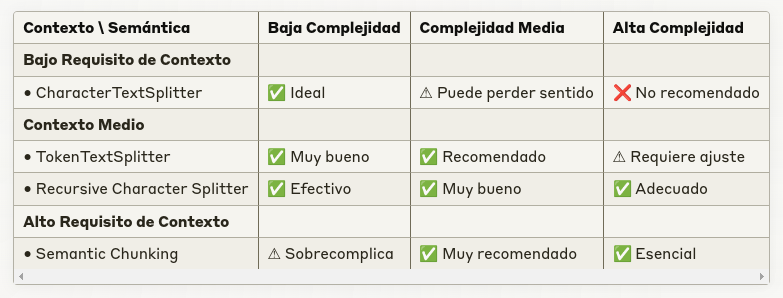

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
'''
Divide de manera jerárquica
Usa múltiples separadores
Preserva mejor la estructura del documento
'''

# Crear un splitter de texto
splitter = RecursiveCharacterTextSplitter(
    separators=["\n\n", "\n", " "],  # Separadores en orden de preferencia
    chunk_size=100,
    chunk_overlap=20
)

# Dividir el documento en chunks
chunks = splitter.split_documents(documento)

print(f"Número de chunks: {len(chunks)}")
print(f"Primer chunk: {chunks[0].page_content}")

**Parámetros RecursiveCharacterTextSplitter**
- separators: List of characters or strings used to split the text (default is ['\n\n', '\n', ' ', '']).
- chunk_size: Maximum size of each chunk in characters.
- chunk_overlap: Number of characters that overlap between consecutive chunks.
- length_function: Function to measure chunk length (default is len).
- is_separator_regex: Whether the separators are treated as regular expressions (default is False).
- keep_separator: Whether to keep the separator in the resulting chunks (default is False).
- add_start_index: Whether to add the start index of each chunk in the original text (default is False).

In [ ]:
python_code="""
def hacer_chunks(self,palabras):
        
        # Lista para almacenar los chunks
        chunks_final = []
        chunks_lista = []
        # Iterar por las palabras para crear chunks
        for i in range(0, len(palabras), self.chunk_size):
            # Crear un chunk con el tamaño especificado
            chunk = palabras[i:i + self.chunk_size]
            
            # Manejar el chunk_overlap
            if chunks_lista and self.chunk_overlap > 0:
                # Tomar los últimos elementos del chunk anterior según el overlap
                overlap = chunks_lista[-1][-self.chunk_overlap:]
                chunk = overlap + chunk
            
            # Convertir el chunk a string con el separador original
            chunk_str = self.separator.join(chunk)
            chunks_lista.append(chunk)
            chunks_final.append(chunk_str)
        
        return chunks_final
"""

In [ ]:
# Crear un tokenizador por caracteres
tokenizador = CharacterTextSplitter(
    separator=" ",
    chunk_size=100,
    chunk_overlap=20
)

# Tokenizar el documento
tokens = tokenizador.split_text(python_code)
print(f"Tokens: {tokens[:10]}") # Mostrar los primeros 10 tokens

In [ ]:
from langchain_text_splitters import PythonCodeTextSplitter
'''
Diseñado para código fuente
Respeta estructura de programación
Mantiene contexto de funciones/clases
'''

splitter = PythonCodeTextSplitter(
    chunk_size=100,    # Líneas de código por chunk
    chunk_overlap=20   # Líneas superpuestas
)

# Dividir el código en chunks
chunks = splitter.split_text(python_code)

# Imprimir los chunks resultantes
for i, chunk in enumerate(chunks, 1):
    print(f"Chunk {i}:\n{chunk}\n")

### Embeddings simples

In [ ]:
from langchain_openai import OpenAIEmbeddings

# Inicializar el modelo de embeddings
embeddings = OpenAIEmbeddings(api_key="")

# Crear embeddings para algunas frases
frases = ["Hola mundo", "Inteligencia artificial", "Procesamiento de lenguaje natural"]
vectores = embeddings.embed_documents(frases)

print(f"Dimensiones del embedding: {len(vectores[0])}")
print(f"Primeros 5 valores del embedding de 'Hola mundo': {vectores[0]}")

### Ejercicio: búsqueda inteligente

Estás desarrollando un sistema de búsqueda inteligente para una biblioteca digital de artículos sobre tecnología. Tu tarea es procesar un artículo sobre Inteligencia Artificial, dividirlo en secciones manejables, y prepararlo para una búsqueda semántica eficiente. Queremos buscar la información relativa a "IA responsable"
Utiliza las técnicas de tokenización, creación de chunks y embeddings para lograr este objetivo. 

**Utiliza las siguientes funciones de apoyo para completar el ejercicio**

Los vectores generados a partir de texto (por ejemplo, utilizando modelos de word embeddings o sentence embeddings) pueden tener magnitudes diferentes debido a la longitud o complejidad del texto. <br>
**La similitud coseno** se utiliza para medir similitudes entre vectores, como los generados a partir de un prompt y una consulta, <br>
porque evalúa exclusivamente la relación de dirección entre los vectores en un espacio de características, ignorando su magnitud.

In [ ]:
import unicodedata
# Función simple para calcular similitud coseno
def similitud_coseno(v1, v2):
    return sum(a*b for a, b in zip(v1, v2)) / (sum(a*a for a in v1)**0.5 * sum(b*b for b in v2)**0.5)

# Consultar un embedding
def consulta(vectores, texto_consulta):
    consulta_embedding = embeddings.embed_query(texto_consulta)
    
    similitudes = [similitud_coseno(consulta_embedding, vec) for vec in vectores]
    chunk_mas_relevante = chunks[similitudes.index(max(similitudes))]
    return chunk_mas_relevante

def limpiar_texto(texto):
    # Normaliza el texto y elimina acentos
    texto_normalizado = unicodedata.normalize('NFKD', texto)
    texto_sin_acentos = ''.join([c for c in texto_normalizado if not unicodedata.combining(c)])
    # Elimina cualquier carácter que no sea ASCII
    texto_limpio = texto_sin_acentos.encode('ascii', 'ignore').decode('ascii')
    return texto_limpio

**Empieza tu código aquí**

In [ ]:
#Paso x. Que no se te olvide hacer los imports necesarios


# Paso 1: Cargar el documento (TextLoader("responsible_IA.txt", encoding="utf-8")) y printea la longitud del documento cargado

# Paso 2: Tokenización y creación de chunks
text_splitter =
chunks = text_splitter.split_documents(documento)
print(f"Número de chunks creados: {len(chunks)}")

textos_limpios = [limpiar_texto(chunk.page_content) for chunk in chunks]

# Paso 3: Crear embeddings para cada chunk
embeddings = 




# Paso 4: Demostración de búsqueda simple
consulta_query = "qué es la IA responsable"

# Paso 5: Llama a la función de consulta
chunk_mas_relevante = consulta(vectores, consulta_query)

print(f"\nPara la consulta '{consulta_query}', el chunk más relevante es:")
print(chunk_mas_relevante.page_content)